# Real-World Implied Volatility, Smile, and Surface

Part 4 of the series, and the payoff for the first three: everything so far has been priced against parameters we chose. Here we pull live option chains from Yahoo Finance via `yfinance`, price a real option, solve for its implied volatility, and build a real volatility smile and surface from actual quoted prices.

**Requires `pip install yfinance` and a live internet connection.**

All the data-fetching and ticker-parsing logic lives in [`optionspricing.market_data`](../src/optionspricing/market_data.py). It parses OCC option symbols with a regex rather than fixed-width string slicing (so it isn't tied to a 4-letter root symbol), and solves implied volatility with the same `implied_volatility_newton` Newton-Raphson solver used in notebook 3 rather than a generic numerical optimiser — reusing our own solver instead of duplicating logic.

In [1]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

from optionspricing import black_scholes_call, black_scholes_put, implied_volatility_newton
from optionspricing.monte_carlo import monte_carlo_price
from optionspricing.market_data import (
    parse_occ_ticker,
    fetch_option_snapshot,
    volatility_smile,
    implied_vol_surface,
)

## Parsing an OCC option ticker

OCC tickers pack the root symbol, expiry, type, and strike into one string, e.g. `AAPL241220C00255000` = AAPL, 2024-12-20, Call, strike 255.00.

In [2]:
parse_occ_ticker('AAPL241220C00255000')

ParsedOccTicker(root='AAPL', expiry=datetime.date(2024, 12, 20), option_type='call', strike=255.0)

## Fetching a live snapshot

`fetch_option_snapshot` pulls the underlying price, the option's last traded price, the 13-week T-bill rate (`^IRX`) as a risk-free rate proxy, and the trailing dividend yield, all in one call.

In [3]:
# Change this to any OCC ticker you want to look at -- see the cell above for the format.
OPTION_TICKER = 'AAPL270917C00225000'

snapshot = fetch_option_snapshot(OPTION_TICKER)
snapshot

OptionSnapshot(ticker='AAPL270917C00225000', root='AAPL', underlying_price=319.9700012207031, strike=225.0, expiry=datetime.date(2027, 9, 17), option_type='call', market_price=110.85, risk_free_rate=0.037400002, dividend_yield=0.0031991713, time_to_expiry=1.0328767123287672)

## Pricing and implied volatility

We solve for the volatility implied by the quoted market price, then use that volatility to cross-check the price via Monte Carlo — the same simulation approach as notebook 3, now fed with a market-implied input instead of an assumed one.

In [4]:
price_fn = black_scholes_call if snapshot.option_type == 'call' else black_scholes_put

iv = implied_volatility_newton(
    snapshot.market_price,
    snapshot.underlying_price,
    snapshot.strike,
    snapshot.time_to_expiry,
    snapshot.risk_free_rate,
    q=snapshot.dividend_yield,
    option_type=snapshot.option_type,
)
print(f'Implied Volatility: {iv:.2%}')

mc_price = monte_carlo_price(
    snapshot.underlying_price,
    snapshot.strike,
    snapshot.time_to_expiry,
    snapshot.risk_free_rate,
    iv,
    option_type=snapshot.option_type,
    q=snapshot.dividend_yield,
)
print(f'Market Price       : {snapshot.market_price:.2f}')
print(f'Monte Carlo Price  : {mc_price:.2f}')
print('The option looks', 'UNDERPRICED' if snapshot.market_price < mc_price else 'OVERPRICED',
      'relative to the Black-Scholes model at its own implied volatility.')
print(f'Time to Expiry (yrs)     : {snapshot.time_to_expiry:.2f}')

Implied Volatility: 38.17%
Market Price       : 110.85
Monte Carlo Price  : 110.29
The option looks OVERPRICED relative to the Black-Scholes model at its own implied volatility.
Time to Expiry (yrs)     : 1.03


### A caveat

"Underpriced/overpriced" here is only relative to Black-Scholes, which is a very simple model. Real markets price options using stochastic volatility, jump risk, liquidity, order flow, supply/demand, market-maker inventory, and hedging pressure — none of which Black-Scholes captures. This isn't a trading signal.

## Volatility smile

For one expiry, implied volatility plotted against strike. Lower-strike options tend to carry higher implied volatility because the market prices in more fear of a large downward move than an equivalent upward one — the volatility skew.

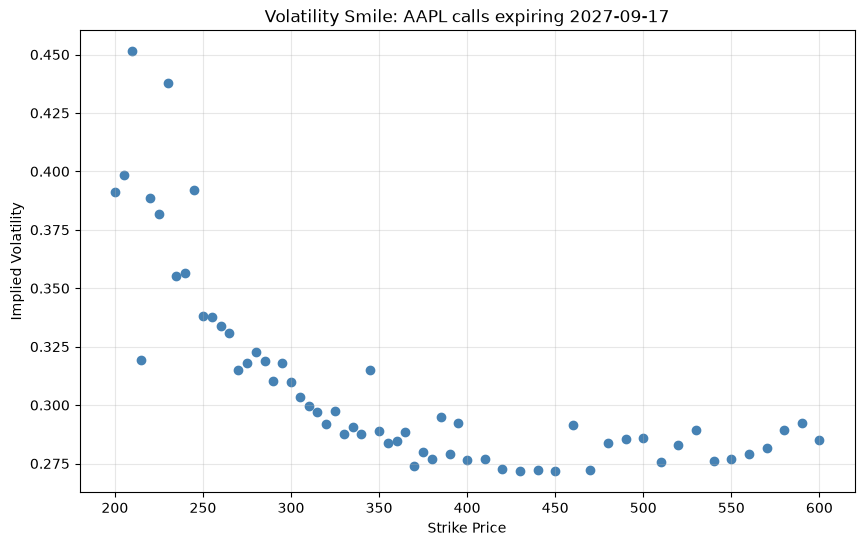

In [5]:
smile = volatility_smile(snapshot.root, snapshot.expiry.strftime('%Y-%m-%d'), snapshot.option_type)

plt.figure(figsize=(10, 6))
plt.scatter(smile['strike'], smile['implied_vol'], color='steelblue')
plt.title(f'Volatility Smile: {snapshot.root} {snapshot.option_type}s expiring {snapshot.expiry}')
plt.xlabel('Strike Price'); plt.ylabel('Implied Volatility')
plt.grid(True, alpha=0.3); plt.show()

Elevated implied vol on out-of-the-money strikes (both calls and puts) reflects the market expecting larger possible moves; a dip near at-the-money often suggests a comparatively stable near-term outlook.

## Implied volatility surface

Extending the smile across every listed expiry gives the surface: strike, time to maturity, and implied volatility together. Every point is solved from a real quoted price with our own `implied_volatility_newton`, not read off Yahoo's own IV column.

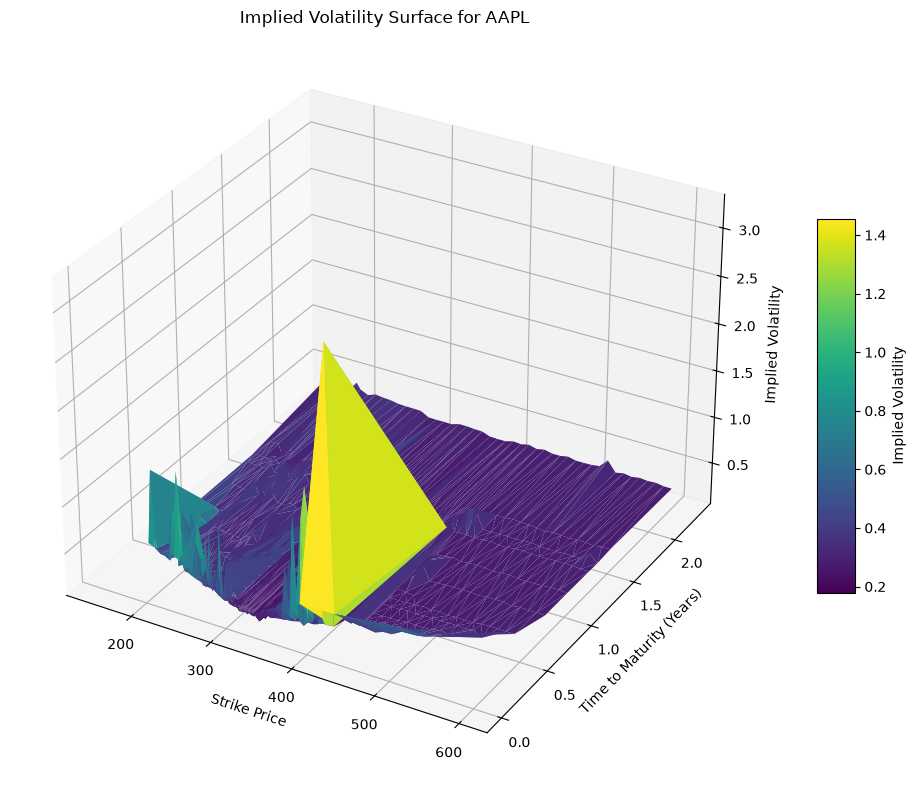

In [6]:
surface_data = implied_vol_surface(snapshot.root, max_expiries=30)

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_trisurf(
    surface_data['strike'], surface_data['time_to_expiry'], surface_data['implied_vol'],
    cmap='viridis', linewidth=0.2, antialiased=True,
)
ax.set_title(f'Implied Volatility Surface for {snapshot.root}')
ax.set_xlabel('Strike Price'); ax.set_ylabel('Time to Maturity (Years)'); ax.set_zlabel('Implied Volatility')
fig.colorbar(surf, shrink=0.5, aspect=10, label='Implied Volatility')
plt.tight_layout(); plt.show()

The surface is the market's live, full-dimensional map of risk pricing across strike and maturity — skew, term structure, and pockets of elevated demand all show up as shape, something a single constant-volatility number can never represent. This closes the loop from notebook 1's flat-sigma assumption to what markets actually do.